In [1]:
%config InlineBackend.figure_formats=['svg']


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import poisson, geom 

In [2]:
def get_attenuation():
    """
    Available attenuations.
    """
    Attenuation = [ 7.,   7.5,  8.,   8.5,  9.,   9.5, 10.,  10.5, 11.,  11.5, 12.,  12.5, 13.,  13.5,
                    14.,  14.5, 15.,  15.5, 16.,  16.5, 17.,  17.5, 18.,  18.5, 19.,  19.5, 20.,  20.5,
                    21.,  21.5, 22.,  22.5, 23.,  23.5, 24.,  24.5, 25.,  25.5, 26.,  26.5, 27.,  27.5,
                    28.,  28.5, 29. ]
    return Attenuation

def get_average():
    """
    Available average photon number.
    """
    Average = [7.08211260e+06, 5.15056588e+06, 3.72436481e+06, 2.71572185e+06,
                1.97472603e+06, 1.42408918e+06, 1.02232317e+06, 7.32125310e+05,
                5.24090642e+05, 3.74998464e+05, 2.66916821e+05, 1.89078950e+05,
                1.35700261e+05, 9.74077327e+04, 6.94691976e+04, 4.90518881e+04,
                3.50311232e+04, 2.50723929e+04, 1.77261578e+04, 1.26385561e+04,
                9.03448510e+03, 6.34776305e+03, 4.44228612e+03, 3.11561879e+03,
                2.20105919e+03, 1.55472974e+03, 1.10119877e+03, 7.74547737e+02,
                5.46214434e+02, 3.86814856e+02, 2.77270797e+02, 1.97954232e+02,
                1.39667657e+02, 9.96796628e+01, 7.12159618e+01, 5.03875460e+01,
                3.56871128e+01, 2.54771649e+01, 1.80622346e+01, 1.27380046e+01,
                9.02367143e+00, 6.40704597e+00, 4.54269070e+00, 3.20272751e+00,
                2.26309906e+00]
    return Average

In [3]:
def uniform(n_arr, amp = 1):
    return amp * np.ones(len(n_arr)) / len(n_arr)

In [4]:
def thermal(n_arr, average):
    n_arr = n_arr.astype('double')
    #n_arr = n_arr +1
    #return average**n_arr / (1+average)**(n_arr+1)
    #return geom(p = average).pmf(k=n_arr)
    return average**n_arr / (average + 1)**(n_arr+1)

In [5]:
def sum_thermal(n_arr, *params):
    #n_arr = n_arr+1
    n_arr = n_arr.astype('double')
    average = get_average()[-len(params):]
    weights = params
    thermal_ = np.zeros(len(n_arr))
    
    for average_, amplitude_ in zip(average, weights):
        thermal_ += amplitude_ *  average_**n_arr / (average_ + 1)**(n_arr+1)
    return thermal_

In [6]:
def geometric(n_arr, average):
    #return geom(p = average).pmf(k=n_arr)
    return average**n_arr * (1-average)

In [7]:
def multi_poisson(n_arr, *params):
    average = get_average()[-len(params):]
    weights = params
    poisson_ = []
    
    for average_, amplitude_ in zip(average, weights):
        poisson_.append(amplitude_ * poisson(mu = average_).pmf(n_arr))
    return poisson_

In [8]:
def sum_poisson(n_arr, *params):
    average = get_average()[-len(params):]
    weights = params
    poisson_ = np.zeros(len(n_arr))
    
    for average_, amplitude_ in zip(average, weights):
        poisson_ += amplitude_ * poisson(mu = average_).pmf(n_arr)
    return poisson_

In [9]:
def single_poisson(n_arr, weight, average):
    return weight * poisson(mu = average).pmf(n_arr)

# Find a distribution

The goal is to find parameters for a known distribution $D_i$ that will follow as closely as possible a goal distribution $D_g$ for a photon number interval from 0 to N.
This is achieved by fitting $D_i$ on $D_g$ considering the probability mass function (PMF) of the distributions.

In [10]:
N1 = 25
N2 = 10_0
N =  N1 + N2
w = 3
n_arr = np.arange(N)
goal_function = np.concatenate([uniform(np.arange(N1), w), np.zeros(N2)])
#goal_function = w*thermal(n_arr, 7)

In [11]:
popt_poisson , _ = curve_fit(sum_poisson, n_arr, goal_function, p0 = [0.1]*15 ,bounds=(0, [1]*15), maxfev=1000)
#popt_thermal , _ = curve_fit(sum_thermal, n_arr, goal_function, p0 = [0.1]*15 ,bounds=(0, [1]*15), maxfev=1000)
popt_single_poisson , _ = curve_fit(single_poisson, n_arr, goal_function)
#popt_single_thermal , _ = curve_fit(thermal, n_arr, goal_function, bounds=(0, 1))
#popt_single_geometric , _ = curve_fit(geometric, n_arr, goal_function, bounds=(0, 1))

In [12]:
print('Sum Poisson : ', *popt_poisson, sep=", ")
print('Single Poisson : ',*popt_single_poisson, sep=", ")
#print('Thermal : ',*popt_single_thermal, sep=", ")
#print('Single Thermal : ',*popt_single_thermal, sep=", ")
#print('Geometric : ',*popt_geometric, sep=", ")

Sum Poisson : , 0.1, 0.18103899837538182, 0.0003478958721172963, 0.0003456379713743067, 0.0003744276723215052, 2.7560595871623853e-07, 5.1048808392493295e-18, 0.28842984940480537, 0.9999999999999999, 0.4483193456686096, 0.34462236788026945, 0.42745454124885873, 6.426683431466243e-24, 3.0632312612371824e-29, 0.4770426849308018
Single Poisson : , 1.6602159930849594, 16.119702599753122


# Plot function

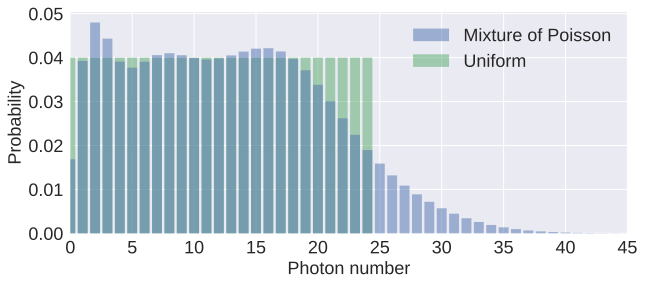

In [14]:
sum_poisson_ = sum_poisson(n_arr, *popt_poisson) / np.sum(sum_poisson(n_arr, *popt_poisson))
goal_function_ = goal_function / np.sum(goal_function)

with plt.style.context("seaborn-v0_8"):
    plt.figure(figsize=(10,4), dpi=200)
    #plt.plot(n_arr, uniform(n_arr, w), label = 'Uniform')
    
    
    #plt.plot(n_arr, single_poisson(n_arr, *popt_single_poisson), label = 'Single Poisson')
    #plt.bar(n_arr, sum_thermal(n_arr, popt_thermal), alpha=0.5, edgecolor='k', label = 'Thermal')
    #plt.bar(n_arr, geometric(n_arr, popt_geometric), alpha=0.5, edgecolor='k', label = 'Geometric')
    plt.bar(n_arr, sum_poisson_, label = 'Mixture of Poisson', alpha=0.5, zorder=2)
    plt.bar(n_arr, goal_function_, label = 'Uniform', alpha=0.5)
    
    #c = [plt.bar(n_arr, poisson_dist, alpha=0.7) for poisson_dist in multi_poisson(n_arr, *popt_poisson)]
    plt.xlim(0,N1+20)
    plt.ylabel('Probability', fontsize=18)
    plt.xlabel('Photon number', fontsize=18)
    plt.legend(fontsize=18)
    plt.yticks(fontsize=18)
    plt.xticks(fontsize=18)
    plt.show()
    plt.savefig('/home/nicolasdc/files/Images/Results/40goal.svg')

# Plot histogram of random values based on previous solutions

To demonstrate that the results from the fit are correct, we use randomly generated samples using the available attenuations and the fitted weights.

<Figure size 800x550 with 0 Axes>

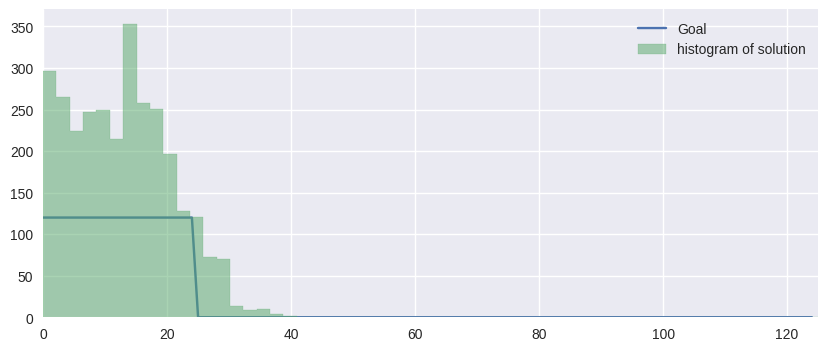

In [63]:
n_rand = 1_000
rand = []

for weight, average in zip(popt_poisson, get_average()[-len(popt_poisson):]):
    rand.append(np.random.poisson(lam = average, 
                               size = int(weight*n_rand)))

result = np.concatenate(rand)

with plt.style.context("seaborn-v0_8"):
    plt.figure(figsize=(10,4), dpi=100)
    plt.plot(n_arr, n_rand * goal_function, label = 'Goal')
    plt.hist(result, 
            bins = len(np.unique(result)),
            fill=True, 
            histtype='step',
            alpha=0.5,
            label='histogram of solution')
    plt.xlim(0,N1+100)
    plt.legend()
    plt.show()

# Problem with using a non-weigthed uniform distribution

When discussing the goal, we did not take into consideration that we want to maximize the number of samples we can use.
By increasing the goal with a weight we can increase the number of samples.
We set the weight arbitrarely for now, which is a sub-optimal solution but it offers an approximation for a solution with a high number of samples.
To demonstrate the effect, a solution with and without a weight of 3 is plotted given we have access to 10 000 samples for every attenuation.

In [64]:
popt_poisson1 , _ = curve_fit(sum_poisson, n_arr, 3*goal_function, p0 = [0.1]*10 ,bounds=(0, [1]*10))
popt_poisson2 , _ = curve_fit(sum_poisson, n_arr, goal_function, p0 = [0.1]*10 ,bounds=(0, [1]*10))

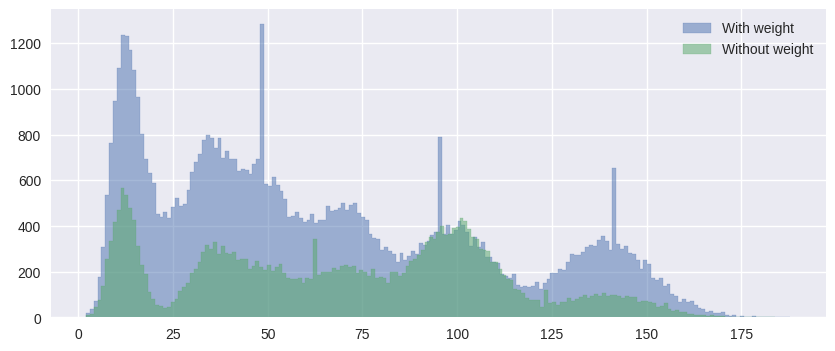

In [65]:
n_rand = 10_000
rand1 = []
rand2 = []

for weight1, weight2, average in zip(popt_poisson1, popt_poisson2, get_average()[-len(popt_poisson):]):
    weight1 = weight1 / np.max(popt_poisson1)
    weight2 = weight2 / np.max(popt_poisson2)
    rand1.append(np.random.poisson(lam = average, 
                               size = int(weight1*n_rand)))
    rand2.append(np.random.poisson(lam = average, 
                               size = int(weight2*n_rand)))

result1 = np.concatenate(rand1)
result2 = np.concatenate(rand2)

with plt.style.context("seaborn-v0_8"):
    plt.figure(figsize=(10,4), dpi=100)
    plt.hist(result1, 
            bins = len(np.unique(result1)),
            fill=True, 
            histtype='step',
            alpha=0.5,
            label='With weight')
    plt.hist(result2, 
            bins = len(np.unique(result2)),
            fill=True, 
            histtype='step',
            alpha=0.5,
            label='Without weight')
    plt.legend()
    plt.show()